In [1]:

# Deneyi farklı kategoriler için tekrarlamak istediğimizde sadece burayı değiştireceğiz.
CATEGORY = "bottle"        # categories = "carpet" , "hazelnut" , "bottle"

print(f"Selected Category:{CATEGORY}")

Selected Category:bottle


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import time
start_time = time.time()
print("\nTimer started. All subsequent computation time will be measured.")


Timer started. All subsequent computation time will be measured.


In [4]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

BASE_DIR = '/content/drive/MyDrive/anomaly_detection_project/dataset/'


train_path = os.path.join(BASE_DIR, CATEGORY, 'train/good/')


image_paths = glob(os.path.join(train_path, '*.png'))
images = []
print(f"'{CATEGORY}' kategorisinden {len(image_paths)} adet eğitim görseli yükleniyo")

for path in tqdm(image_paths, desc=f"'{CATEGORY}' için eğitim verileri işleniyor"):

    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    image_resized = cv2.resize(image, (256, 256))

    image_flattened = image_resized.flatten()
    images.append(image_flattened)


X_train_svm = np.array(images)

print("\nEğitim verisi başarıyla yüklendi ve One-Class SVM için hazırlandı!")
print(f"Oluşturulan veri matrisinin boyutu: {X_train_svm.shape}")

'bottle' kategorisinden 209 adet eğitim görseli yükleniyo


'bottle' için eğitim verileri işleniyor: 100%|██████████| 209/209 [00:16<00:00, 13.03it/s]


Eğitim verisi başarıyla yüklendi ve One-Class SVM için hazırlandı!
Oluşturulan veri matrisinin boyutu: (209, 65536)


In [5]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler


print(f"'{CATEGORY}' kategorisi için ön işleme: Veri ölçeklendirme başlatılıyor")

scaler = StandardScaler()

X_train_svm_scaled = scaler.fit_transform(X_train_svm)

print("Veri ölçeklendirme tamamlandı")
print(f"Ölçeklenmiş eğitim verisinin boyutu: {X_train_svm_scaled.shape}")



print(f"\n'{CATEGORY}' kategorisi için One-Class SVM modeli oluşturuluyor ve eğitiliyo")


svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)

svm_model.fit(X_train_svm_scaled)

print(f"\n'{CATEGORY}' kategorisi için One-Class SVM modeli başarıyla eğitildi")

'bottle' kategorisi için ön işleme: Veri ölçeklendirme başlatılıyor
Veri ölçeklendirme tamamlandı
Ölçeklenmiş eğitim verisinin boyutu: (209, 65536)

'bottle' kategorisi için One-Class SVM modeli oluşturuluyor ve eğitiliyo

'bottle' kategorisi için One-Class SVM modeli başarıyla eğitildi


In [6]:
print(f"--- '{CATEGORY.capitalize()}' için One-Class SVM Test Aşaması ---")


test_path = os.path.join(BASE_DIR, CATEGORY, 'test/')


X_test_svm = []
y_true_svm = []

print(f"'{CATEGORY}' kategorisi için test verileri yükleniyor ve işleniyor")

test_folders = [f for f in glob(os.path.join(test_path, '*')) if os.path.isdir(f)]

for folder_path in tqdm(test_folders, desc=f"'{CATEGORY}' test klasörleri yükleniyor"):
    label_name = os.path.basename(folder_path)
    image_paths_test = glob(os.path.join(folder_path, '*.png'))

    for path in image_paths_test:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        image_resized = cv2.resize(image, (256, 256))
        image_flattened = image_resized.flatten()
        X_test_svm.append(image_flattened)

        # (1: normal, -1: anomali)
        if label_name == 'good':
            y_true_svm.append(1)
        else:
            y_true_svm.append(-1)


X_test_svm = np.array(X_test_svm)
y_true_svm = np.array(y_true_svm)
print(f"\n'{CATEGORY}' için test verileri başarıyla yüklendi")
print(f"Test veri matrisinin boyutu: {X_test_svm.shape}")


print("\nTest verileri, eğitim setine göre öğrenilen scaler ile ölçeklendiriliyor")

X_test_svm_scaled = scaler.transform(X_test_svm)
print("Test verileri başarıyla ölçeklendirildi")


print(f"\nEğitilmiş SVM modeli ile '{CATEGORY}' test verileri üzerinde tahmin yapılıyor")
y_pred_svm = svm_model.predict(X_test_svm_scaled)
print("Tahmin işlemi tamamlandı!")
print(f"Tahmin edilen etiketlerin boyutu: {y_pred_svm.shape}")

--- 'Bottle' için One-Class SVM Test Aşaması ---
'bottle' kategorisi için test verileri yükleniyor ve işleniyor


'bottle' test klasörleri yükleniyor: 100%|██████████| 4/4 [00:43<00:00, 11.00s/it]



'bottle' için test verileri başarıyla yüklendi
Test veri matrisinin boyutu: (83, 65536)

Test verileri, eğitim setine göre öğrenilen scaler ile ölçeklendiriliyor
Test verileri başarıyla ölçeklendirildi!

Eğitilmiş SVM modeli ile 'bottle' test verileri üzerinde tahmin yapılıyor
Tahmin işlemi tamamlandı!
Tahmin edilen etiketlerin boyutu: (83,)


--- One-Class SVM Performance for 'Bottle': Classification Report ---
              precision    recall  f1-score   support

Anomaly (-1)       0.88      0.95      0.92        63
  Normal (1)       0.80      0.60      0.69        20

    accuracy                           0.87        83
   macro avg       0.84      0.78      0.80        83
weighted avg       0.86      0.87      0.86        83


--- One-Class SVM Performance for 'Bottle': Confusion Matrix ---


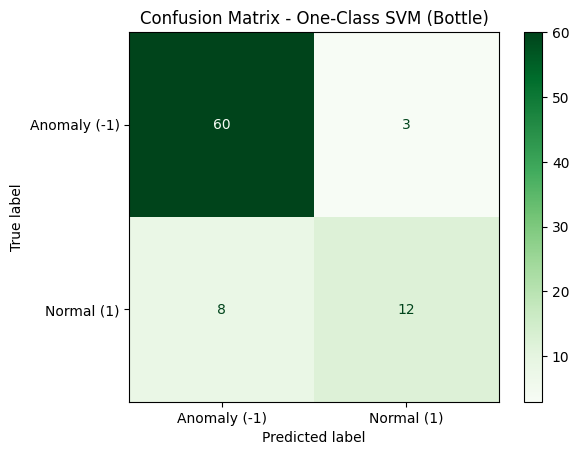

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(f"--- One-Class SVM Performance for '{CATEGORY.capitalize()}': Classification Report ---")

#
target_names = ['Anomaly (-1)', 'Normal (1)']
print(classification_report(y_true_svm, y_pred_svm, target_names=target_names, zero_division=0))

print(f"\n--- One-Class SVM Performance for '{CATEGORY.capitalize()}': Confusion Matrix ---")


ConfusionMatrixDisplay.from_predictions(y_true_svm,
                                        y_pred_svm,
                                        display_labels=target_names,
                                        cmap=plt.cm.Greens)
plt.title(f"Confusion Matrix - One-Class SVM ({CATEGORY.capitalize()})")
plt.show()


--- One-Class SVM Performance for 'Bottle': AUROC Score ---
Calculated AUROC Score for 'Bottle' (SVM): 0.9484


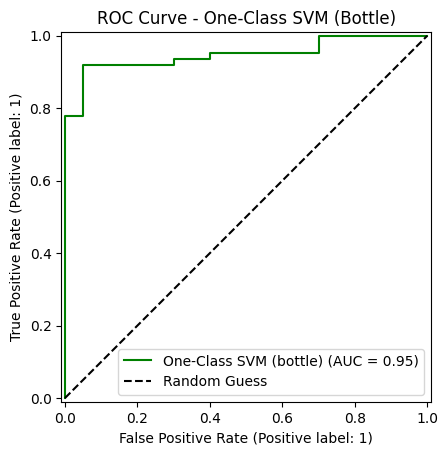

In [8]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print(f"\n--- One-Class SVM Performance for '{CATEGORY.capitalize()}': AUROC Score ---")


svm_scores = svm_model.decision_function(X_test_svm_scaled)


y_scores_svm = -svm_scores


y_true_for_roc_svm = [0 if x == 1 else 1 for x in y_true_svm]


auroc_svm = roc_auc_score(y_true_for_roc_svm, y_scores_svm)
print(f"Calculated AUROC Score for '{CATEGORY.capitalize()}' (SVM): {auroc_svm:.4f}")


RocCurveDisplay.from_predictions(y_true_for_roc_svm, y_scores_svm, name=f"One-Class SVM ({CATEGORY})", color="green")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve - One-Class SVM ({CATEGORY.capitalize()})")
plt.legend()
plt.show()

In [9]:

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\n--- Total Computation Time ---")
print(f"The process took {elapsed_time:.2f} seconds.")
print(f"({elapsed_time / 60:.2f} minutes)")


--- Total Computation Time ---
The process took 65.41 seconds.
(1.09 minutes)
